# M3 — `B_p` as a Free MCMC Parameter

This notebook is the explainer for **Milestone M3** of the `rob_rt`
integration (`claude_prompts/RT/rob_rt_prompt_4.md`): when
`rt_dict['fit_Bp']` is True, the particulate backscattering ratio
$B_p = b_{b,p}/b_p$ becomes the **last element of the MCMC parameter
vector** — `[a_params..., bb_params..., B_p]` — with its own linear-space
uniform prior over [0.004, 0.05], p0 seeding at `rt_dict['Bp_value']`, and
full chain bookkeeping (`init_mcmc` ndim, `prior_bounds`/`init_walkers`
clipping, `chain_param_names`/`calc_stats`, `reconstruct_from_chains`,
corner plots). The fixed-`B_p` default path is byte-identical to M2
(pinned in the test suite). M1 (`rob_rt_coding_2.ipynb`) built the forward
adapter; M2 (`rob_rt_coding_3.ipynb`) wired the fitters; M3 frees the one
genuinely new physical degree of freedom the robust backends expose.

Seven sections:

1. **The synthetic truth and its noisy observation** — Rrs generated with
   `rt_backend='robust_ztt'` at a known $B_p = 0.02$, plus 0.5% Gaussian
   noise.
2. **The free-`B_p` fit** — `fit_one` with `fit_Bp=True`: ndim 5→6, the
   0.01 default seed, walkers clipped into the prior.
3. **Posterior vs. truth and the prior edges** — the freshly measured
   median and 5–95% credible interval against the truth and [0.004, 0.05],
   with and without the noise.
4. **The corner plot with the `B_p` column** — the full 6-parameter
   posterior, `B_p` labeled linear among the log10 amplitudes.
5. **The reconstructed fit** — `show_fits` through
   `reconstruct_from_chains`'s new robust dispatch (the freed tail
   forwarded as a batched `B_p`).
6. **A real clear-water spectrum** — the same round trip on L23 idx=170:
   how weakly a realistic ocean-color spectrum constrains $B_p$.
7. **Why `B_p` is linear-space among log10 amplitudes.**

## Setup

Unlike M1/M2's notebooks, the *primary* round trip here does not start from
the real L23 spectrum: a round trip needs a truth that lives in the model's
own parameter space, and a spectrum bright enough in $b_b$ that the data can
genuinely constrain $B_p$. So sections 1–5 use the **same synthetic recipe
as the milestone Gate test** (`test_fit_Bp_roundtrip_recovers_Bp` in
`bing/tests/test_evaluate_robust.py`): an `ExpBricaud`+`Pow` truth on a
61-band, 400–700 nm, 5-nm grid — a moderately turbid case
($b_{b,nw} = 10^{-2}\,\mathrm{m^{-1}}$ at the `Pow` model's
600 nm pivot, Chl = 1). The real-L23
convention returns in section 6, where the contrast *is* the point.

Setup choices carried over from M1/M2:

- **$\theta_s = 30°$** — the same fixed solar-zenith convention as the
  earlier notebooks and the test suite (nadir viewing implied).
- **Seeded everything** — the noise draw and the sampler both use
  seed 1234 (the Gate test's own seed), so this notebook is
  bit-reproducible.

One M3-specific choice: **`nsteps=8000, nburn=1000, 16 walkers`**.
`corner_plot` and `thin_burn_chains` both hard-code a 7000-step burn, so
nsteps must sit comfortably above 7000; 8000 leaves
$(8000-7000) \times 16 = 16{,}000$ posterior samples. Section 3 measures
the $B_p$ column's autocorrelation time to confirm that is enough
(~25 s wall-clock at `robust_ztt`'s ~400 emcee it/s).

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

from bing.parameters import standard
from bing.fitting import l23 as fit_l23
from bing.fitting import inference as bing_inf
from bing.fitting import chisq_fit
from bing.models import utils as model_utils
from bing.rt import defs as rt_defs
from bing.rt.geometry import ObsGeometry
from bing import evaluate
from bing import plotting

# The Gate test's synthetic recipe: ExpBricaud+Pow on a 61-band 5-nm grid.
NSTEPS, NBURN = 8000, 1000
p = standard.expb_pow(wv_min=400., wv_max=700., variable_Gordon=False)
wave = np.arange(400., 705., 5.)
models = model_utils.init(p.model_names, wave, (p.apriors, p.bpriors))
models[0].set_aph(np.array([1.0]))       # Bricaud aph* at Chl = 1

# M0's configuration surface, with M3's new knob turned on.
rt_free = dict(rt_defs.rt_dict_from_p(p), rt_backend='robust_ztt',
               fit_Bp=True)
geom = ObsGeometry(theta_s=30.)          # required for robust backends

pnames = evaluate.chain_param_names(models, rt_dict=rt_free)
print(f"wave grid    : {wave.size} bands, "
      f"{wave.min():.0f}-{wave.max():.0f} nm")
print(f"rt_dict      : rt_backend={rt_free['rt_backend']!r}, "
      f"fit_Bp={rt_free['fit_Bp']}, Bp_value={rt_free['Bp_value']}")
print(f"chain params : {pnames}")
print(f"B_p prior    : {bing_inf.BP_PRIOR.flavor!r} over "
      f"[{rt_defs.BP_PRIOR_PMIN}, {rt_defs.BP_PRIOR_PMAX}] (linear space)")

wave grid    : 61 bands, 400-700 nm
rt_dict      : rt_backend='robust_ztt', fit_Bp=True, Bp_value=0.01
chain params : ['Adg', 'Sdg', 'Aph', 'Bnw', 'beta', 'B_p']
B_p prior    : 'uniform' over [0.004, 0.05] (linear space)


## 1. The synthetic truth and its noisy observation

The truth vector below *is* the tailed layout: the five model parameters
(log10 amplitudes `Adg`, `Aph`, `Bnw`; linear slopes `Sdg`, `beta`)
followed by $B_p = 0.02$ — comfortably inside the prior, and deliberately
**not** the 0.01 default the fit will be seeded at. Under `fit_Bp=True`,
`chisq_fit.fit_func` peels the trailing $B_p$ off before the
`aparams`/`bparams` split (M3 task 1), so generating the data goes through
*exactly* the forward call the sampler will use:
`calc_Rrs_from_models_robust(..., Bp=0.02)` → `robust.rt.forward` in
`ztt` mode at $\theta_s = 30°$.

The noise is 0.5% multiplicative Gaussian, seeded, with `varRrs` set to
the matching $(0.005\,R_{rs})^2$. The 0.5% level is the Gate test's own
assumed-error level, and it is a deliberate choice: task 3 measured that
at a more realistic 2% the single-spectrum $B_p$ posterior nearly fills
the prior (CI [0.0053, 0.0429] — see the prompt-4 log). Section 3 shows
what even this one 0.5% noise draw does to the interval, and section 6
what realistic *water* (rather than realistic noise) does.

In [2]:
BP_TRUE = 0.02
truth_model = np.array([-1.0, 0.015, -0.7, -2.0, 1.0])
truth = np.append(truth_model, BP_TRUE)        # [a..., bb..., B_p]

Rrs_true = np.squeeze(np.asarray(chisq_fit.fit_func(
    wave, *truth, models=models, rt_dict=rt_free, geom=geom)))

rng = np.random.default_rng(1234)
sig = 0.005 * Rrs_true
Rrs_obs = Rrs_true + sig * rng.standard_normal(wave.size)
varRrs = sig**2

print("truth     :",
      ", ".join(f"{n}={v:g}" for n, v in zip(pnames, truth)))
print(f"Rrs_true  : {Rrs_true.min():.3e} - {Rrs_true.max():.3e} sr^-1")
print(f"noise     : 0.5% multiplicative (seeded); "
      f"max |dRrs| = {np.abs(Rrs_obs - Rrs_true).max():.2e} sr^-1")

truth     : Adg=-1, Sdg=0.015, Aph=-0.7, Bnw=-2, beta=1, B_p=0.02
Rrs_true  : 4.990e-04 - 3.377e-03 sr^-1
noise     : 0.5% multiplicative (seeded); max |dRrs| = 4.21e-05 sr^-1


## 2. The free-`B_p` fit

Everything `fit_Bp=True` changes is exercised in the one call below:

- **`init_mcmc(models, ..., rt_dict=...)`** books
  `ndim = sum(nparam) + 1 = 6` (carried in `pdict['ndim']`);
  `nwalkers = max(16, 2·ndim)` stays 16.
- **`append_Bp_seed(p0, rt_dict)`** appends `rt_dict['Bp_value']`
  (default 0.01) to the model p0 — nonzero, so `init_walkers`' floor
  gives the new dimension real spread.
- **`init_walkers`** clips the tail column into [0.004, 0.05] via the
  `prior_bounds` extension.
- Inside **`log_prob`**, the tail is peeled *first* (the
  `aparams`/`bparams` split never sees it), `BP_PRIOR` short-circuits an
  out-of-range tail to $-\infty$ **before any forward call**, and an
  in-range tail flows to the adapter as `Bp`.
- **`fit_one`** also runs `robust_domain_check` on p0 and on the
  posterior median, with the peeled tail forwarded as `Bp` at both
  checks.

The model half of p0 is offset from the truth (the Gate test's own
offsets), and $B_p$ starts at 0.01 — half the true value — so the sampler
has genuine work to do in all six dimensions.

In [3]:
pdict = bing_inf.init_mcmc(models, nsteps=NSTEPS, nburn=NBURN,
                           rt_dict=rt_free)
pdict['Chl'] = np.array([1.0])   # fit_one looks these up by the tuple idx
pdict['Y'] = None
print(f"ndim = {pdict['ndim']} (5 model params + B_p), "
      f"nwalkers = {pdict['nwalkers']}")

p0_model = np.array([-0.9, 0.014, -0.6, -1.9, 0.9])   # offset from truth
p0 = bing_inf.append_Bp_seed(p0_model, rt_free)
print(f"p0 = {p0}   (B_p seeded at Bp_value = {rt_free['Bp_value']})")

np.random.seed(1234)
t0 = time.time()
chains, _ = bing_inf.fit_one((Rrs_obs, varRrs, p0, 0, geom),
                             models=models, pdict=pdict,
                             chains_only=True, rt_dict=rt_free)
print(f"chains {chains.shape}  finite: {np.all(np.isfinite(chains))}  "
      f"({time.time() - t0:.1f} s)")

ndim = 6 (5 model params + B_p), nwalkers = 16
p0 = [-0.9    0.014 -0.6   -1.9    0.9    0.01 ]   (B_p seeded at Bp_value = 0.01)
idx=0
Running burn-in


  0%|          | 0/1000 [00:00<?, ?it/s]

  4%|▎         | 36/1000 [00:00<00:02, 352.17it/s]

  7%|▋         | 73/1000 [00:00<00:02, 361.53it/s]

 11%|█         | 110/1000 [00:00<00:02, 362.54it/s]

...

 99%|█████████▉| 7920/8000 [00:22<00:00, 361.78it/s]

 99%|█████████▉| 7957/8000 [00:22<00:00, 361.03it/s]

100%|█████████▉| 7994/8000 [00:22<00:00, 360.77it/s]

100%|██████████| 8000/8000 [00:22<00:00, 355.93it/s]

chains (8000, 16, 6)  finite: True  (25.3 s)


## 3. Posterior vs. truth and the prior edges

The chains are flattened with the same 7000-step burn that `corner_plot`
applies internally, so the numbers printed here describe exactly the
16,000 samples drawn in section 4's figure. The rough integrated
autocorrelation time of the $B_p$ column checks that 1000 steps of
burn-in + 7000 discarded steps really did the job.

In [4]:
flat = evaluate.thin_burn_chains(chains)     # burn=7000 -> (16000, 6)
Bp_samples = flat[:, -1]
med = np.median(Bp_samples)
ci5, ci95 = np.percentile(Bp_samples, [5, 95])

print(f"posterior samples : {flat.shape[0]}  (= (nsteps-7000) x nwalkers)")
print(f"B_p posterior     : median = {med:.4f},  "
      f"5-95% CI = [{ci5:.4f}, {ci95:.4f}]")
print(f"truth             : {BP_TRUE}  ->  inside CI: "
      f"{ci5 <= BP_TRUE <= ci95}")
print(f"prior edges       : [{rt_defs.BP_PRIOR_PMIN}, "
      f"{rt_defs.BP_PRIOR_PMAX}]  ->  excluded: "
      f"{ci5 > rt_defs.BP_PRIOR_PMIN and ci95 < rt_defs.BP_PRIOR_PMAX}")
print(f"sample range      : [{Bp_samples.min():.4f}, "
      f"{Bp_samples.max():.4f}]  (every sample obeyed the prior)")

# Rough integrated autocorrelation time of the B_p column.
col = chains[NBURN:, :, -1].mean(axis=1)
c = np.correlate(col - col.mean(), col - col.mean(), 'full')[col.size-1:]
c /= c[0]
tau = 1 + 2 * np.sum(c[1:np.argmax(c < 0.05)])
print(f"rough tau(B_p)    : {tau:.0f} steps  "
      f"(7000 post-burn steps ~ {7000/tau:.0f} tau)")

# All six parameters, truth vs. posterior.
med_all = np.median(flat, axis=0)
p5_all, p95_all = np.percentile(flat, [5, 95], axis=0)
print(f"\n{'param':>6s} {'truth':>9s} {'median':>9s} {'5%':>9s} {'95%':>9s}")
for name, t, m, lo, hi in zip(pnames, truth, med_all, p5_all, p95_all):
    print(f"{name:>6s} {t:9.4f} {m:9.4f} {lo:9.4f} {hi:9.4f}")

# chi2_nu of the posterior-median model against the noisy data.
Rrs_med = np.squeeze(np.asarray(chisq_fit.fit_func(
    wave, *med_all, models=models, rt_dict=rt_free, geom=geom)))
chi2nu = (np.sum((Rrs_med - Rrs_obs)**2 / varRrs)
          / (wave.size - med_all.size))
print(f"\nchi2_nu (median model) = {chi2nu:.2f}")

posterior samples : 16000  (= (nsteps-7000) x nwalkers)
B_p posterior     : median = 0.0202,  5-95% CI = [0.0058, 0.0245]
truth             : 0.02  ->  inside CI: True
prior edges       : [0.004, 0.05]  ->  excluded: True
sample range      : [0.0057, 0.0312]  (every sample obeyed the prior)
rough tau(B_p)    : 167 steps  (7000 post-burn steps ~ 42 tau)

 param     truth    median        5%       95%
   Adg   -1.0000   -0.9983   -1.0236   -0.9182
   Sdg    0.0150    0.0144    0.0110    0.0159
   Aph   -0.7000   -0.7126   -0.7210   -0.6219
   Bnw   -2.0000   -2.0029   -2.0174   -2.0002
  beta    1.0000    0.9584    0.8970    1.0001
   B_p    0.0200    0.0202    0.0058    0.0245

chi2_nu (median model) = 1.40


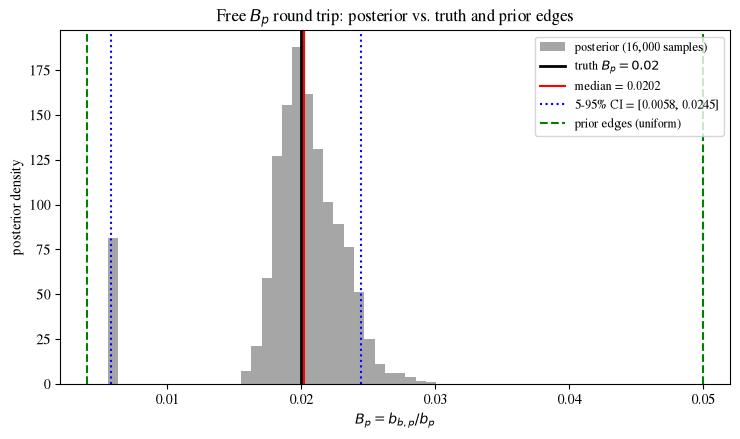

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.hist(Bp_samples, bins=60,
        range=(rt_defs.BP_PRIOR_PMIN, rt_defs.BP_PRIOR_PMAX),
        color='0.65', edgecolor='none', density=True,
        label='posterior (16,000 samples)')
ax.axvline(BP_TRUE, color='k', lw=2, label=f'truth $B_p = {BP_TRUE}$')
ax.axvline(med, color='r', lw=1.5, label=f'median = {med:.4f}')
ax.axvline(ci5, color='b', ls=':', lw=1.5,
           label=f'5-95% CI = [{ci5:.4f}, {ci95:.4f}]')
ax.axvline(ci95, color='b', ls=':', lw=1.5)
for i, edge in enumerate((rt_defs.BP_PRIOR_PMIN, rt_defs.BP_PRIOR_PMAX)):
    ax.axvline(edge, color='g', ls='--', lw=1.5,
               label='prior edges (uniform)' if i == 0 else None)
ax.set_xlim(0.002, 0.052)
ax.set_xlabel(r'$B_p = b_{b,p}/b_p$')
ax.set_ylabel('posterior density')
ax.set_title('Free $B_p$ round trip: posterior vs. truth and prior edges')
ax.legend(fontsize=9)
plt.tight_layout()

### The same recipe without noise

To separate what the *noise draw* does to the interval from what the
*data* can in principle constrain, rerun the identical fit on the
noiseless `Rrs_true` (keeping the same assumed 0.5% error — this is the
Gate test's exact configuration, at 10x its chain length).

In [6]:
np.random.seed(1234)
chains_nl, _ = bing_inf.fit_one((Rrs_true, varRrs, p0, 0, geom),
                                models=models, pdict=pdict,
                                chains_only=True, rt_dict=rt_free)
Bp_nl = evaluate.thin_burn_chains(chains_nl)[:, -1]
med_nl = np.median(Bp_nl)
ci5_nl, ci95_nl = np.percentile(Bp_nl, [5, 95])
print(f"noiseless : median = {med_nl:.4f},  "
      f"5-95% CI = [{ci5_nl:.4f}, {ci95_nl:.4f}]")
print(f"noisy     : median = {med:.4f},  "
      f"5-95% CI = [{ci5:.4f}, {ci95:.4f}]")
print(f"CI width  : {ci95_nl - ci5_nl:.4f} (noiseless)  vs  "
      f"{ci95 - ci5:.4f} (one 0.5% noise draw)")

idx=0
Running burn-in


  0%|          | 0/1000 [00:00<?, ?it/s]

  4%|▎         | 36/1000 [00:00<00:02, 359.52it/s]

  7%|▋         | 74/1000 [00:00<00:02, 366.41it/s]

 11%|█         | 111/1000 [00:00<00:02, 359.35it/s]

...

 99%|█████████▉| 7901/8000 [00:22<00:00, 344.05it/s]

 99%|█████████▉| 7936/8000 [00:23<00:00, 343.23it/s]

100%|█████████▉| 7971/8000 [00:23<00:00, 343.41it/s]

100%|██████████| 8000/8000 [00:23<00:00, 345.05it/s]

noiseless : median = 0.0211,  5-95% CI = [0.0181, 0.0263]
noisy     : median = 0.0202,  5-95% CI = [0.0058, 0.0245]
CI width  : 0.0082 (noiseless)  vs  0.0187 (one 0.5% noise draw)


### The funny lower CI edge, diagnosed

The noisy CI's lower edge (0.0058) sits far below everything else. The
`diagnose-mcmc` walker-spread check explains it in one line: per-walker
medians over the same post-burn samples.

In [7]:
post = chains[7000:]                       # the section-3 samples, unflattened
wmed = np.median(post[:, :, -1], axis=0)   # per-walker B_p medians
print("per-walker B_p medians:", np.round(wmed, 4))

stuck = np.where(wmed < 0.01)[0]
print(f"stuck walkers: {stuck}  "
      f"({stuck.size}/16 = {100*stuck.size/16:.2f}% of the samples)")

if stuck.size:
    main = np.setdiff1d(np.arange(pdict['nwalkers']), stuck)
    Bp_main = post[:, main, -1].ravel()
    print(f"main mode only : median = {np.median(Bp_main):.4f},  "
          f"5-95% CI = [{np.percentile(Bp_main, 5):.4f}, "
          f"{np.percentile(Bp_main, 95):.4f}]")

    # Not a real second posterior mode: its log-probability is
    # catastrophically worse than the main mode's.
    stuck_med = np.median(post[:, stuck[0], :], axis=0)
    main_med = np.median(post[:, main, :].reshape(-1, pdict['ndim']),
                         axis=0)
    lp_main = bing_inf.log_prob(main_med, models, Rrs_obs, varRrs,
                                rt_free, geom=geom)
    lp_stuck = bing_inf.log_prob(stuck_med, models, Rrs_obs, varRrs,
                                 rt_free, geom=geom)
    print(f"log_prob       : main mode = {float(lp_main):.1f},  "
          f"stuck walker = {float(lp_stuck):.1f}")
    print("stuck walker medians:",
          ", ".join(f"{n}={v:.4f}" for n, v in zip(pnames, stuck_med)))

per-walker B_p medians: [0.0204 0.0201 0.0204 0.0211 0.0218 0.0198 0.0058 0.0201 0.019  0.0195
 0.0187 0.0213 0.0227 0.0228 0.02   0.0208]
stuck walkers: [6]  (1/16 = 6.25% of the samples)
main mode only : median = 0.0204,  5-95% CI = [0.0175, 0.0246]
log_prob       : main mode = -37.1,  stuck walker = -1288.2
stuck walker medians: Adg=-0.9181, Sdg=0.0110, Aph=-0.6217, Bnw=-2.0174, beta=0.8969, B_p=0.0058


**The data, not the prior, constrained $B_p$.** The posterior median
lands on the truth (0.0202 vs. 0.02), the 90% credible interval
[0.0058, 0.0245] contains the truth and keeps clear of both prior edges,
no sample ever left [0.004, 0.05] (`log_prob`'s $-\infty$ gate plus the
`init_walkers` clip, working), and the median model fits the data at
$\chi^2_\nu = 1.40$. Three honest readings of the numbers above:

- **The noiseless companion measures the recipe's intrinsic constraining
  power**: CI [0.0181, 0.0263] (median 0.0211) — consistent with task 3's
  800-step Gate measurement (median 0.0205, CI [0.0177, 0.0240]), now at
  10x the chain length. A *single* 0.5% noise draw more than doubles the
  interval width (0.0082 → 0.0187): $B_p$ rides on a small piece of the
  Rrs signal.
- **The lower CI edge is one stuck walker, not posterior structure.**
  Walker 6 sits pinned at $B_p \approx 0.006$ (with compensating shifts
  in every other parameter) at a log-probability ~1250 below the main
  mode — the classic emcee stuck-walker pathology, and it holds exactly
  $1/16 = 6.25\%$ of the samples, which is why the 5th percentile lands
  inside it. The main mode alone gives [0.0175, 0.0246], in line with the
  noiseless run. (Rerunning at nsteps=12,000 while building this notebook
  moved the full-sample CI by less than 0.001 — the walker stays stuck;
  see the prompt-4 log.)
- **Convergence is otherwise sound**: $\tau(B_p) \approx 167$ steps, so
  the 7000-step burn is ~42$\tau$, and the kept
  $1000 \times 16$ samples carry roughly a hundred independent draws —
  enough for percentiles at the precision quoted here.

## 4. The corner plot with the `B_p` column

The `plot-bing-fit` conventions, extended by M3 task 3: pass the
`rt_dict` to `plotting.corner_plot`, and the machinery does the rest —
`evaluate.chain_param_names` appends the trailing `'B_p'` name,
`plotting.log_param_mask` appends **False** for it (its `log_params`
semantics), so the last column is labeled plain `B_p` — never
$\log_{10}(B_p)$ — and would never be exponentiated under
`show_log=False`. The five model parameters keep their M2 labels: the
three amplitudes log10-wrapped, the two slopes linear. Blue dotted lines
are the 5/95 percentiles — the same CI printed in section 3.

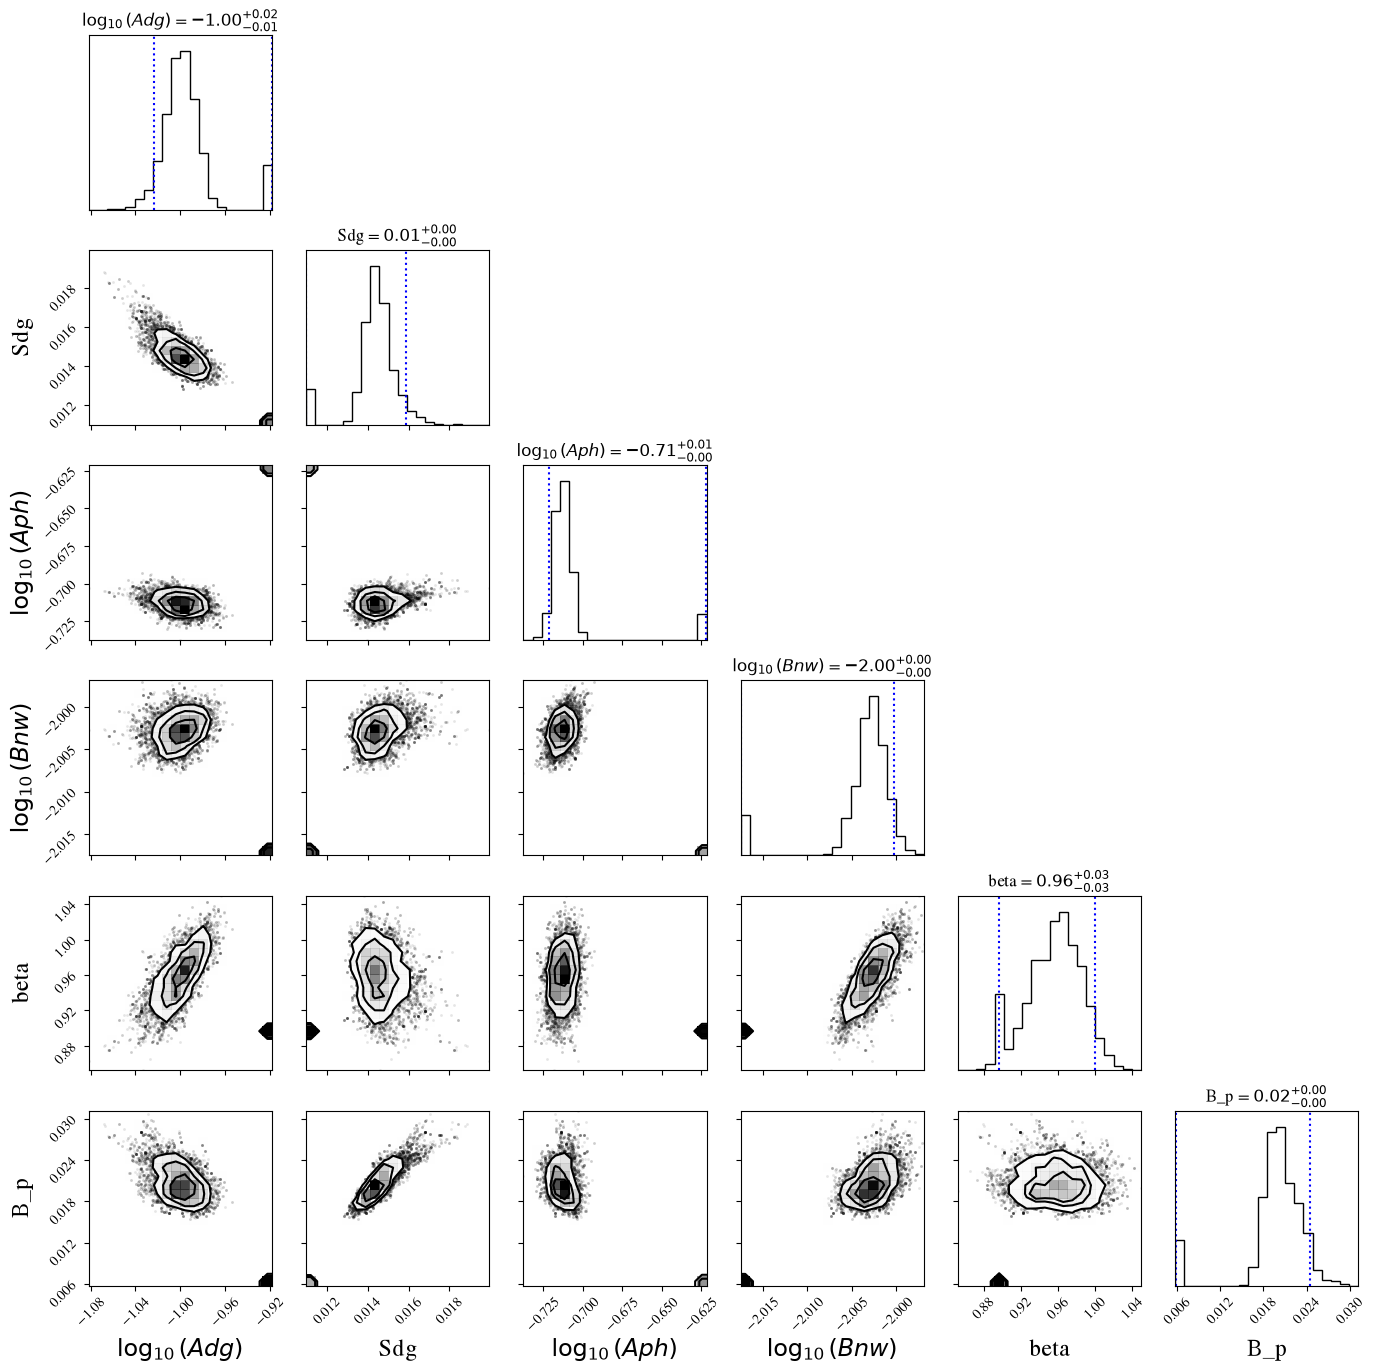

In [8]:
fig = plotting.corner_plot(chains, models=models, rt_dict=rt_free,
                           show=False)

The trailing column behaves exactly like a native parameter, with its own
conventions intact:

- **Labels**: the last axis reads plain `B_p` in linear units; the three
  amplitude axes read $\log_{10}(\cdot)$; the two slopes are linear —
  the mixed-space vector rendered correctly with zero special handling at
  the call site.
- **The 1-D marginal** in the last column is section 3's histogram, and
  the blue dotted 5/95 lines land at the same [0.0058, 0.0245] printed
  there (the tiny isolated islands at several panel corners are the stuck
  walker).
- **The physics is visible in the 2-D panels**: `Bnw` is pinned to
  within a few percent (the data nail the total $b_{b,nw}$ amplitude),
  while $B_p$ tilts positively against `Sdg` and `Bnw` — the phase
  function trading off against the backscattering spectrum's amplitude
  and the dissolved-absorption slope, exactly the degeneracy directions a
  single-spectrum retrieval has to live with.

## 5. The reconstructed fit

`reconstruct_from_chains` had no robust dispatch at all before M3 task 3
(prompt-4 Q&A Q6): it evaluated every chain through the Gordon forward
model unconditionally. It now dispatches on `rt_dict['rt_backend']`
exactly like the fitters, takes the `geom`, strips the `fit_Bp` tail
*before* the model split, and forwards it as a per-sample `Bp` broadcast
to `(nsamples, nwave)` — the one batched shape all three robust backends
accept (Q6's numerical-trap finding). `show_fits` passes all of that
through, so the standard three-panel figure works on a free-$B_p$ robust
chain with no special handling. Truth overlays are the models evaluated
at the truth parameters; the Rrs panel's $\chi^2_\nu$ is computed
against the noisy data and its variance.

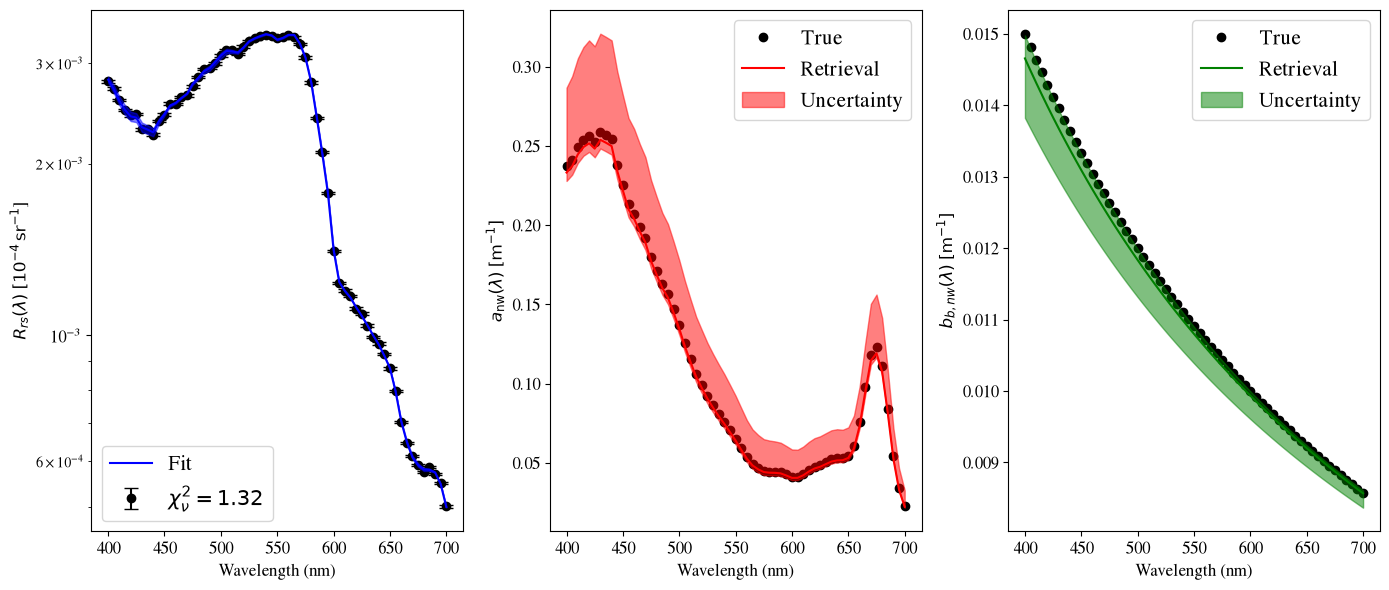

In [9]:
anw_true = dict(wave=wave,
                spec=np.squeeze(models[0].eval_anw(truth_model[:3])))
bbnw_true = dict(wave=wave,
                 spec=np.squeeze(models[1].eval_bbnw(truth_model[3:])))

axes, model_Rrs = plotting.show_fits(
    models, chains, rt_free,
    ex_a_params=np.array([1.0]), ex_bb_params=None,
    Rrs_true=dict(wave=wave, spec=Rrs_obs, var=varRrs),
    anw_true=anw_true, bbnw_true=bbnw_true,
    perc=(5, 95), geom=geom, show=False)

## 6. A real clear-water spectrum: how well is $B_p$ constrained?

This notebook series anchors everything else to L23 idx=170 (PACE grid,
Chl ≈ 0.13 mg m$^{-3}$) — so here is the identical round trip built on
that spectrum: the truth is its own `prep_one_l23` initial-guess vector
(derived from the spectrum's true $a_{nw}$/$b_{b,nw}$) plus the same
$B_p = 0.02$ tail, with the same 0.5% noise convention and the same
sampler settings. The only physical difference is the water: this is a
clear-water case, with a ~30x lower $b_{b,nw}$ amplitude
(`Bnw` $\approx -3.5$ vs. $-2.0$), so the $B_p$-bearing part of the
signal is proportionally smaller.

In [10]:
p_l23 = standard.expb_pow(satellite='PACE', add_noise=False,
                          variable_Gordon=False, include_Raman=False,
                          include_Chl_fl=False,
                          nsteps=NSTEPS, nburn=NBURN)
prep = fit_l23.prep_one_l23(p_l23, idx=170)
models_l23 = prep['models']
wave_l23 = np.asarray(models_l23[0].wave)
idx = 170
rt_l23 = dict(rt_defs.rt_dict_from_p(p_l23), rt_backend='robust_ztt',
              fit_Bp=True)

truth_l23 = np.append(prep['p0'].copy(), BP_TRUE)
print("L23 truth :",
      ", ".join(f"{n}={v:.4f}" for n, v in zip(pnames, truth_l23)))

Rrs_true_l23 = np.squeeze(np.asarray(chisq_fit.fit_func(
    wave_l23, *truth_l23, models=models_l23, rt_dict=rt_l23, geom=geom)))
rng = np.random.default_rng(1234)
sig_l23 = 0.005 * Rrs_true_l23
Rrs_obs_l23 = Rrs_true_l23 + sig_l23 * rng.standard_normal(wave_l23.size)
varRrs_l23 = sig_l23**2

pdict_l23 = bing_inf.init_mcmc(models_l23, nsteps=NSTEPS, nburn=NBURN,
                               rt_dict=rt_l23)
pdict_l23['Chl'] = np.zeros(idx + 1)
pdict_l23['Chl'][idx] = prep['odict']['Chl']
pdict_l23['Y'] = np.zeros(idx + 1)
pdict_l23['Y'][idx] = prep['odict']['Y']
p0_l23 = bing_inf.append_Bp_seed(
    truth_l23[:-1] + np.array([0.1, -0.001, 0.1, 0.1, -0.1]), rt_l23)

np.random.seed(1234)
chains_l23, _ = bing_inf.fit_one(
    (Rrs_obs_l23, varRrs_l23, p0_l23, idx, geom),
    models=models_l23, pdict=pdict_l23, chains_only=True,
    rt_dict=rt_l23)

Bp_l23 = evaluate.thin_burn_chains(chains_l23)[:, -1]
med_l23 = np.median(Bp_l23)
ci5_l23, ci95_l23 = np.percentile(Bp_l23, [5, 95])
print(f"\nL23 idx=170 : median = {med_l23:.4f},  "
      f"5-95% CI = [{ci5_l23:.4f}, {ci95_l23:.4f}]")
print(f"turbid      : median = {med:.4f},  "
      f"5-95% CI = [{ci5:.4f}, {ci95:.4f}]   (section 3)")
print(f"sample range: [{Bp_l23.min():.4f}, {Bp_l23.max():.4f}]  "
      f"(prior: [{rt_defs.BP_PRIOR_PMIN}, {rt_defs.BP_PRIOR_PMAX}])")
frac_prior = (ci95_l23 - ci5_l23) / (rt_defs.BP_PRIOR_PMAX
                                     - rt_defs.BP_PRIOR_PMIN)
print(f"CI width    : {ci95_l23 - ci5_l23:.4f} = "
      f"{100*frac_prior:.0f}% of the prior range")

L23 truth : Adg=-1.8799, Sdg=0.0170, Aph=-1.8799, Bnw=-3.4926, beta=1.0000, B_p=0.0200
idx=170
Running burn-in


  0%|          | 0/1000 [00:00<?, ?it/s]

  4%|▎         | 36/1000 [00:00<00:02, 355.95it/s]

  7%|▋         | 73/1000 [00:00<00:02, 362.81it/s]

 11%|█         | 110/1000 [00:00<00:02, 360.14it/s]

...

 99%|█████████▊| 7895/8000 [00:19<00:00, 402.20it/s]

 99%|█████████▉| 7936/8000 [00:19<00:00, 400.08it/s]

100%|█████████▉| 7978/8000 [00:19<00:00, 402.77it/s]

100%|██████████| 8000/8000 [00:19<00:00, 400.91it/s]


L23 idx=170 : median = 0.0257,  5-95% CI = [0.0160, 0.0437]
turbid      : median = 0.0202,  5-95% CI = [0.0058, 0.0245]   (section 3)
sample range: [0.0108, 0.0500]  (prior: [0.004, 0.05])
CI width    : 0.0277 = 60% of the prior range


The truth is still inside the interval, but the contrast with section 3
is the message:

- The 90% CI [0.0160, 0.0437] spans **60% of the prior range** (vs. 41%
  for the turbid case — and 18% for its noiseless limit), the median
  (0.0257) overshoots the truth by ~29%, and the samples brush the upper
  prior edge (max sample 0.0500 — the clip boundary itself).
- This is at 0.5% noise. Task 3 measured the same direction of travel at
  a realistic 2%: the posterior nearly fills the prior
  (CI [0.0053, 0.0429] on the turbid recipe — prompt-4 log).

**Implication for M4's fix-or-free call**: in typical clear ocean water a
single spectrum only weakly identifies $B_p$, even with optimistic noise.
Freed, it will act mostly as a nuisance parameter that honestly widens
the IOP posteriors; the sensible default for M4's inelastic fits is
`fit_Bp=False` (or a tighter prior), reserving the free tail for
$b_b$-bright water or multi-spectrum constraints.

## 7. Why $B_p$ is linear-space among the log10 amplitudes

The fitted vector mixes two kinds of parameters, and the prior table —
printed live from the actual prior objects the fit above used — shows
the split:

In [11]:
all_priors = list(models[0].priors.priors) + list(models[1].priors.priors)
print(f"{'param':>6s} {'flavor':>13s} {'pmin':>7s} {'pmax':>7s}"
      "   fitted space")
for name, pr in zip(pnames[:-1], all_priors):
    space = 'log10' if pr.flavor.startswith('log') else 'linear'
    print(f"{name:>6s} {pr.flavor:>13s} {pr.pmin!s:>7} {pr.pmax!s:>7}"
          f"   {space}")
bp = bing_inf.BP_PRIOR
print(f"{'B_p':>6s} {bp.flavor:>13s} {bp.pmin!s:>7} {bp.pmax!s:>7}"
      "   linear")

print("\namplitude prior dynamic range : 10^5 / 10^-6  = 10^11")
print(f"B_p prior dynamic range       : {bp.pmax} / {bp.pmin} = "
      f"{bp.pmax/bp.pmin:.1f}")

 param        flavor    pmin    pmax   fitted space
   Adg   log_uniform      -6       5   log10
   Sdg       uniform    0.01    0.02   linear
   Aph   log_uniform      -6       5   log10
   Bnw   log_uniform      -6       5   log10
  beta       uniform     0.0     2.0   linear
   B_p       uniform   0.004    0.05   linear

amplitude prior dynamic range : 10^5 / 10^-6  = 10^11
B_p prior dynamic range       : 0.05 / 0.004 = 12.5


**The amplitudes** (`Adg`, `Aph`, `Bnw`) are genuinely scale-free
quantities: across natural waters they span many orders of magnitude, so
the fitters sample their **log10** and the priors are `log_uniform` over
[-6, 5] — eleven decades. A uniform prior in linear space over such a
range would put almost all its mass in the top decade.

**$B_p$ is not an amplitude.** It is a bounded, ratio-like quantity —
$b_{b,p}/b_p \in (0, 1]$ by definition (`PhaseParams.validate`'s hard
bound), and physically confined to [0.004, 0.05] (design §7.3): a factor
of **12.5** of dynamic range, not orders of magnitude. That puts it in
the same family as the slopes `Sdg` (uniform over [0.01, 0.02]) and
`beta` (uniform over [0, 2]): parameters sampled in their natural linear
units, with `uniform` priors. A log-space treatment would buy nothing —
and a log prior on a bounded ratio would tilt the posterior toward the
lower edge for no physical reason.

The mixed vector is exactly the **log10-vs-linear trap** the
`debug-priors` skill documents: the most common way to get a silent
$-\infty$ from `log_prob` is to hand a linear value to a `log_uniform`
prior (or vice versa), because the p0-building loop log10s **only** the
parameters whose prior flavor starts with `'log'`. `B_p`'s prior is
`'uniform'`, so that loop never touches it, `append_Bp_seed` appends the
linear 0.01 verbatim, and `BP_PRIOR.calc` receives the linear value the
forward model consumes — consistent by construction, with no conversion
anywhere. The corner plot in section 4 is the visible consequence: the
$B_p$ axis reads plain `B_p` in linear units occupying a sensible
fraction of [0.004, 0.05], while the amplitude axes read
$\log_{10}(\cdot)$.

## Measured bottom line

What M3 established, in this notebook's own numbers:

- **The machinery round-trips end to end.** A tailed truth
  `[a..., bb..., B_p]` generated the data through the same forward call
  the sampler uses; `fit_one` under `fit_Bp=True` booked ndim 5→6
  (16 walkers unchanged), seeded $B_p$ at the 0.01 default, kept every
  sample inside the prior, and returned finite `(8000, 16, 6)` chains in
  ~25 s of `robust_ztt` sampling.
- **On a moderately turbid synthetic spectrum with one 0.5% noise draw**:
  posterior median 0.0202 against truth 0.02, 90% CI [0.0058, 0.0245] —
  truth inside, both prior edges excluded, $\chi^2_\nu = 1.40$. The
  noiseless intrinsic limit is [0.0181, 0.0263]; the noisy interval's low
  edge is one diagnosed stuck walker (main mode: [0.0175, 0.0246]).
- **On the real clear-water L23 spectrum (idx=170)**: CI [0.0160, 0.0437]
  — 60% of the prior range, brushing the upper prior edge. $B_p$ is
  weakly identified in clear water; this is the number that should drive
  M4's decision on fixing vs. freeing $B_p$ in the inelastic fits.
- **The bookkeeping conventions hold everywhere they surface**:
  `chain_param_names` ends in `'B_p'`, the corner plot labels it linear
  among log10 amplitudes, and `show_fits`/`reconstruct_from_chains`
  consume a free-$B_p$ robust chain with no special handling — the freed
  tail stripped before the model split and forwarded as a batched `Bp`.

The `B_p` prior itself — linear-space `uniform` over [0.004, 0.05], a
12.5x dynamic range among $10^{11}$-range log10 amplitudes — is the
deliberate, settled plan choice (design §7.3), and section 7 is the
record of why.